In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

In [2]:
#load data
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv"

usarrests = pd.read_csv(url)

usarrests.head()

,rownames,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6


In [4]:
#set statenames as index
usarrests = usarrests.set_index("rownames")

usarrests.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [5]:
#standardize data
scaler = StandardScaler()

usarrests_scaled = scaler.fit_transform(usarrests)

In [8]:
#hierarchical clustering
hc_complete = linkage(
    usarrests_scaled,
    method="complete",
    metric="euclidean"
)

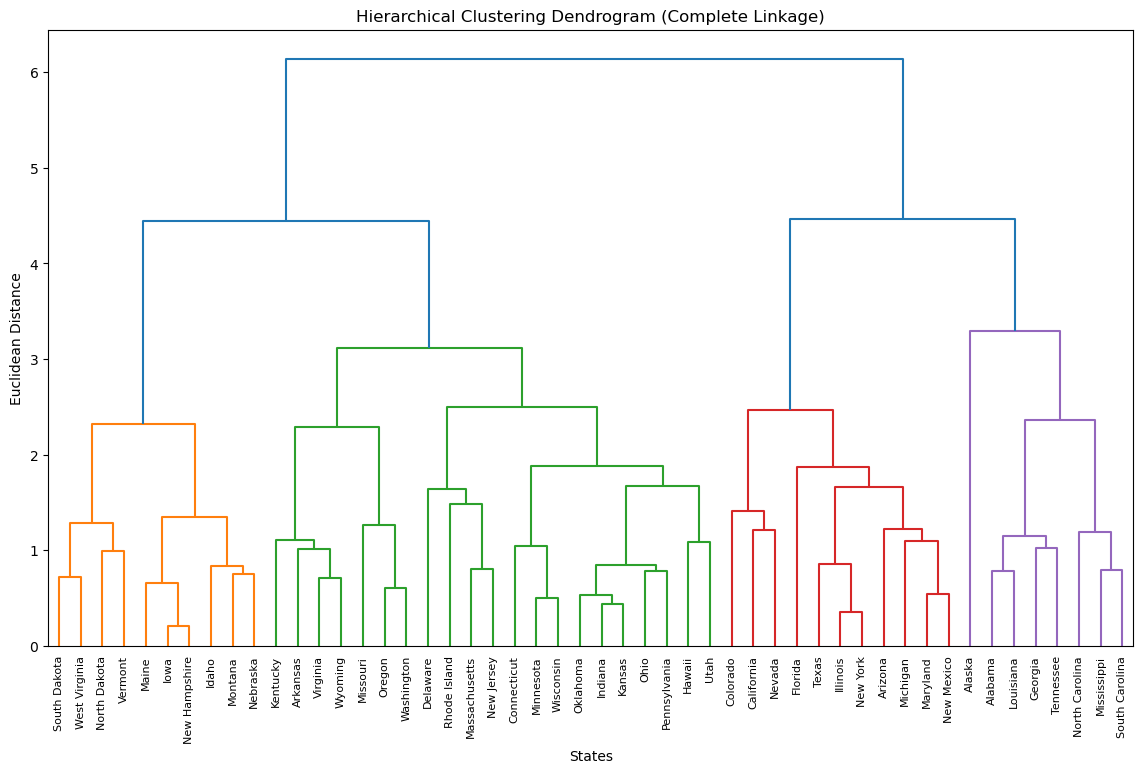

In [9]:
#dendrogram
plt.figure(figsize=(14,8))

dendrogram(
    hc_complete,
    labels=usarrests.index,
    leaf_rotation=90
)

plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
plt.xlabel("States")
plt.ylabel("Euclidean Distance")

plt.show()

## Interpretation of Hierarchical Clustering

Hierarchical clustering using complete linkage and Euclidean distance was applied to the USArrests dataset after standardizing the variables. The dendrogram illustrates how states are grouped together based on similarities in crime-related statistics, including Murder, Assault, UrbanPop, and Rape rates.

States with similar crime profiles clustered together at lower linkage distances, while states with substantially different crime patterns merged at higher distances in the dendrogram. Complete linkage clustering tends to create compact clusters by maximizing the distance between observations in different groups. The dendrogram provides a visual representation of the hierarchical relationships among the states and helps identify potential clusters based on similarity in arrest and crime characteristics.

In [10]:
#cut dendrogram - 3 clusters
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(
    hc_complete,
    3,
    criterion="maxclust"
)

cluster_df = pd.DataFrame({
    "State": usarrests.index,
    "Cluster": clusters
})

cluster_df = cluster_df.sort_values("Cluster")

cluster_df

,State,Cluster
3,Arkansas,1
7,Delaware,1
6,Connecticut,1
15,Kansas,1
13,Indiana,1
14,Iowa,1
10,Hawaii,1
11,Idaho,1
24,Missouri,1
25,Montana,1


In [11]:
#view states by cluster
for i in range(1, 4):
    print(f"\nCluster {i} States:")
    print(cluster_df[cluster_df["Cluster"] == i]["State"].tolist())


Cluster 1 States:
['Arkansas', 'Delaware', 'Connecticut', 'Kansas', 'Indiana', 'Iowa', 'Hawaii', 'Idaho', 'Missouri', 'Montana', 'Nebraska', 'New Hampshire', 'Massachusetts', 'Minnesota', 'Maine', 'Kentucky', 'New Jersey', 'Utah', 'Wisconsin', 'Wyoming', 'Vermont', 'Virginia', 'West Virginia', 'Washington', 'South Dakota', 'Oklahoma', 'Pennsylvania', 'Rhode Island', 'Oregon', 'North Dakota', 'Ohio']

Cluster 2 States:
['Nevada', 'Arizona', 'Florida', 'California', 'Colorado', 'Illinois', 'Michigan', 'New York', 'New Mexico', 'Texas', 'Maryland']

Cluster 3 States:
['Louisiana', 'Georgia', 'Alabama', 'Mississippi', 'Alaska', 'North Carolina', 'Tennessee', 'South Carolina']


## Interpretation of Three-Cluster Solution

The dendrogram was cut at a height that produced three distinct clusters of states. States within the same cluster share similar crime and arrest characteristics based on the variables included in the USArrests dataset. The clustering results indicate that certain groups of states exhibit similar levels of violent crime, urban population percentages, and arrest patterns.

One cluster generally contains states with lower crime rates, another contains states with moderate crime levels, and the final cluster contains states with relatively higher violent crime and assault rates. Hierarchical clustering effectively grouped states according to similarities in their crime-related statistics, allowing patterns among states to be visually and quantitatively identified.

## Interpretation of Hierarchical Clustering After Scaling

The variables in the USArrests dataset were standardized prior to clustering so that each variable had mean zero and standard deviation one. Scaling was necessary because the variables were measured on different scales, and hierarchical clustering using Euclidean distance is sensitive to variable magnitude. Without scaling, variables with larger numeric ranges, such as Assault, would dominate the clustering results.

After standardization, hierarchical clustering with complete linkage and Euclidean distance was performed again. The resulting dendrogram reflected clustering patterns based on the relative structure of all variables rather than being disproportionately influenced by any single variable. Scaling allowed each crime-related variable to contribute equally to the distance calculations and produced a more balanced and interpretable clustering solution.

## Effect of Scaling on Hierarchical Clustering

Scaling the variables had a substantial effect on the hierarchical clustering results. Before scaling, variables with larger numeric ranges, particularly Assault, had a much stronger influence on the Euclidean distance calculations. As a result, the clustering structure was driven primarily by differences in assault rates rather than by the combined contribution of all variables in the dataset. After scaling the variables to have standard deviation one, each variable contributed equally to the computation of inter-observation dissimilarities, resulting in a more balanced clustering solution.

In this case, the variables should be scaled before computing the inter-observation dissimilarities. The variables in the USArrests dataset are measured on different scales and represent different types of crime statistics. Without scaling, variables with larger magnitudes dominate the clustering process and can distort the results. Standardizing the variables ensures that no single variable disproportionately influences the clustering outcome and allows the analysis to better reflect the overall similarity structure among the states. Therefore, scaling produces a more interpretable and statistically appropriate hierarchical clustering solution.